In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [4]:
df = pd.read_csv('ai_financial_market_daily_realistic_synthetic.csv')
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


In [6]:
#show basic info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [ ]:
#convert datatype of date column into datetime format

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [11]:
#ccreate new column for year

df['Year'] = df['Date'].dt.year
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015
...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66,2024
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57,2024
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52,2024
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22,2024


1) How much amount the companies spent on R & D ?

In [12]:
print("Companies spending for R & D in $Bn")

RD = df.groupby('Company')['R&D_Spending_USD_Mn'].sum()/1000
RD

Companies spending for R & D in $Bn


Company
Google    423.34114
Meta      264.53307
OpenAI     26.48277
Name: R&D_Spending_USD_Mn, dtype: float64

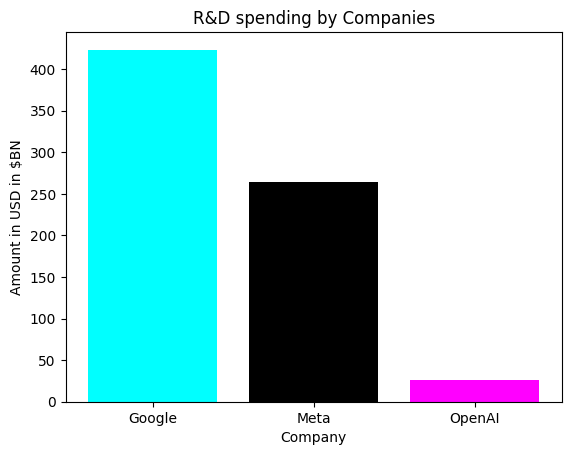

In [13]:
#draw bar plot to show amount spent on R&D BY companies

plt.bar(RD.index, RD.values, color = ['cyan', 'black', 'magenta'])

plt.title("R&D spending by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")
plt.show()

2 REVENUE EARNED BY THE COMPANIES

In [16]:
rev = df.groupby("Company")["AI_Revenue_USD_Mn"].sum()/1000   #BY DIVIDING 1000 CONVERTING IT INTO BILLIONS
rev

Company
Google    284.49838
Meta      189.62182
OpenAI      9.46289
Name: AI_Revenue_USD_Mn, dtype: float64

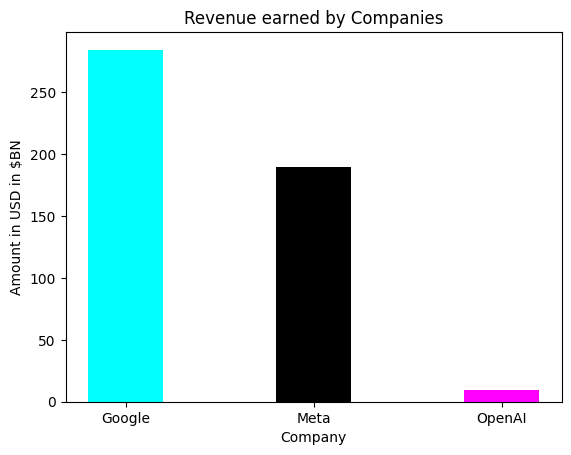

In [17]:
#draw bar plot to show revenue earned BY companies
plt.bar(rev.index, rev.values, color = ['cyan', 'black', 'magenta'], width=0.4)

plt.title("Revenue earned by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")
plt.show()

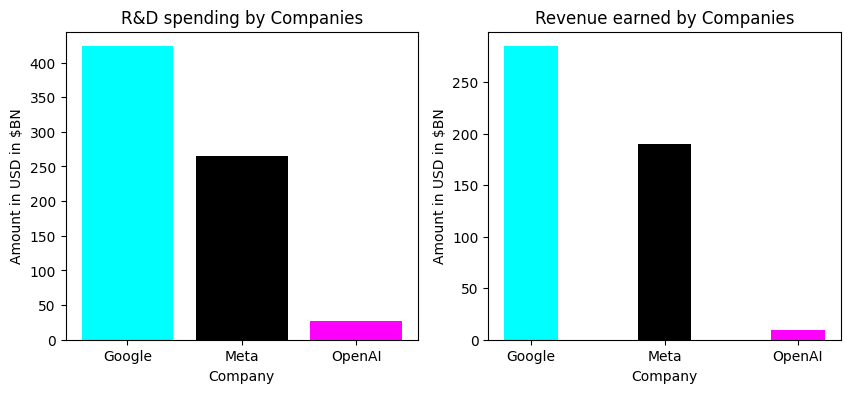

In [18]:
#bar plot to show expenditure and revenue of companies

plt.figure(figsize= (10,4))

plt.subplot(1, 2, 1)

plt.bar(RD.index, RD.values, color = ['cyan', 'black', 'magenta'])

plt.title("R&D spending by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")

plt.subplot(1, 2, 2)

plt.bar(rev.index, rev.values, color = ['cyan', 'black', 'magenta'], width=0.4)

plt.title("Revenue earned by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")

plt.show()

3 Date-wise Impact on the Stock

        Date  Stock_Impact_%
0 2015-01-01       -0.266667
1 2015-01-02        0.020000
2 2015-01-03        0.580000
3 2015-01-04        0.086667
4 2015-01-05       -0.413333


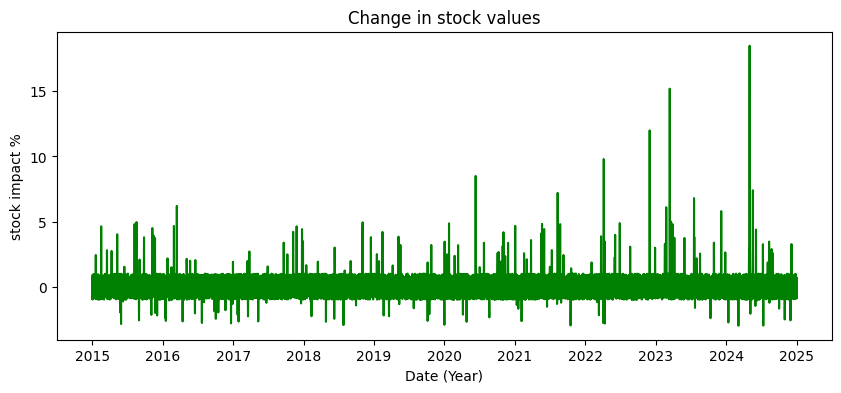

In [24]:
date_wise_impact = (
    df.groupby("Date")["Stock_Impact_%"]
      .mean()
      .reset_index()
)
print(date_wise_impact.head(5))

plt.figure(figsize= (10,4))
plt.plot(df['Date'], df['Stock_Impact_%'], color = 'green')
plt.title("Change in stock values")
plt.xlabel("Date (Year)")
plt.ylabel("stock impact %")
plt.show()

4 Create separate dataframes

In [11]:
data_openAI = df[df['Company'] == 'OpenAI']
data_openAI

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69


In [6]:
data_google = df[df['Company'] == 'Google']
data_meta = df[df['Company'] == 'Meta']

In [7]:
data_google

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
3653,2015-01-01,Google,79.89,30.19,0.64,NaN,-0.02
3654,2015-01-02,Google,78.99,30.44,1.47,NaN,-0.98
3655,2015-01-03,Google,79.20,30.46,1.53,NaN,0.78
3656,2015-01-04,Google,79.59,30.55,1.82,NaN,-0.41
3657,2015-01-05,Google,81.50,30.59,1.97,NaN,-0.78
...,...,...,...,...,...,...,...
7301,2024-12-27,Google,162.16,155.36,417.88,NaN,-0.46
7302,2024-12-28,Google,159.69,154.47,414.89,NaN,-0.48
7303,2024-12-29,Google,161.69,154.59,415.31,NaN,0.72
7304,2024-12-30,Google,158.48,155.05,416.84,NaN,-0.17


In [8]:
data_meta

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
7306,2015-01-01,Meta,50.39,18.95,-5.23,NaN,-0.42
7307,2015-01-02,Meta,49.80,19.77,-1.16,NaN,0.63
7308,2015-01-03,Meta,49.09,19.96,-0.21,NaN,0.73
7309,2015-01-04,Meta,50.66,20.48,2.38,NaN,-0.26
7310,2015-01-05,Meta,51.36,19.84,-0.80,NaN,-0.37
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


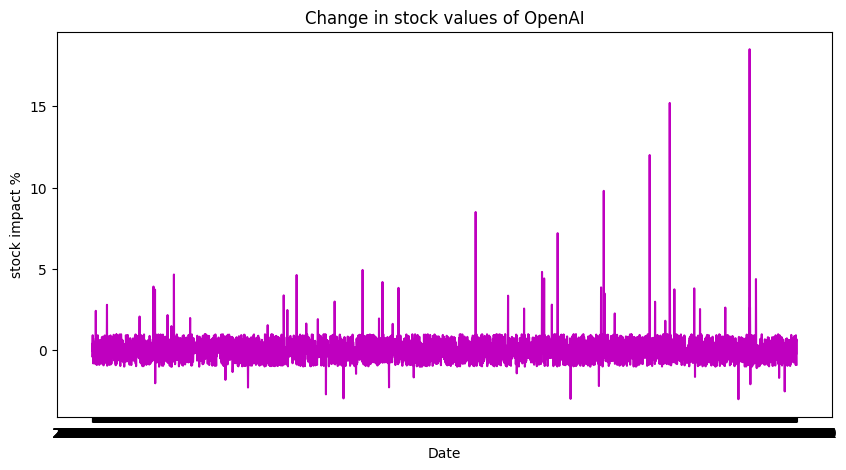

In [12]:
plt.figure(figsize= (10,5))
plt.plot(data_openAI['Date'], data_openAI['Stock_Impact_%'], color = 'm')

plt.title("Change in stock values of OpenAI")
plt.xlabel("Date")
plt.ylabel("stock impact %")
plt.show()

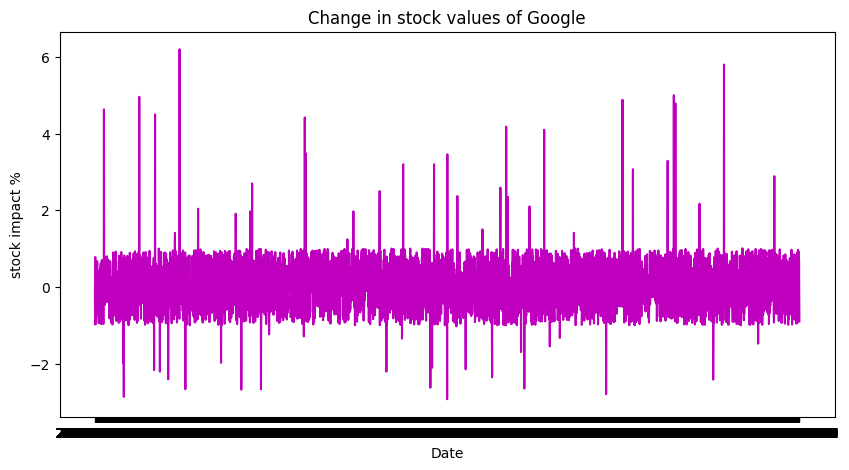

In [15]:
plt.figure(figsize= (10,5))

plt.plot(data_google['Date'], data_google['Stock_Impact_%'], color = 'm')

plt.title("Change in stock values of Google")
plt.xlabel("Date")
plt.ylabel("stock impact %")
plt.show()

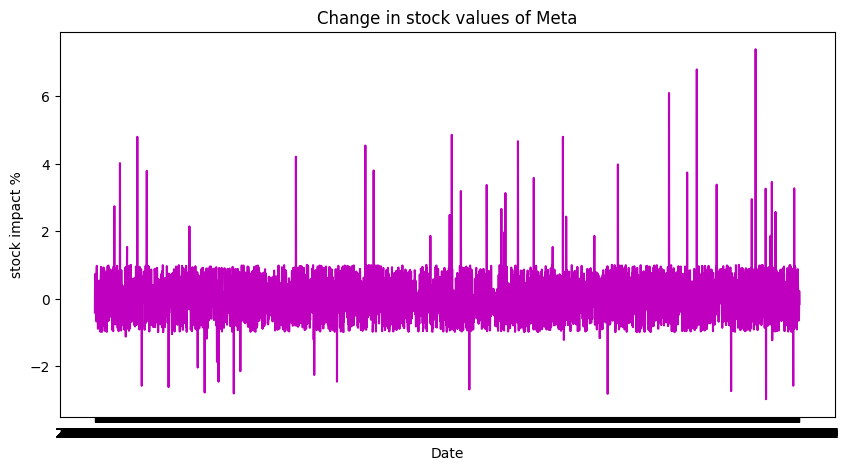

In [14]:
plt.figure(figsize= (10,5))

plt.plot(data_meta['Date'], data_meta['Stock_Impact_%'], color = 'm')

plt.title("Change in stock values of Meta")
plt.xlabel("Date")
plt.ylabel("stock impact %")

plt.show()